# Exploratory Data Analysis: discipline_results_ingest Table

This notebook provides a comprehensive exploration of the swimming competition results data stored in the `discipline_results_ingest` table. We'll examine the data structure, quality, and key characteristics to understand the dataset better and identify any potential issues or interesting patterns.

**Objective**: Understand the structure, quality, and characteristics of the swimming results data before further analysis or production processing.

In [1]:
# Import necessary libraries
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path to import custom modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from database import Database

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


## Connect to Database and Load Data

We'll connect to the SQLite database using the custom `Database` class and load the `discipline_results_ingest` table into a pandas DataFrame for analysis.

In [2]:
# Connect to the database
db_path = '../../swim_database_2.sqlite3'
db = Database(db_path)

print(f"Successfully connected to database: {db_path}")
print(f"Database file exists: {os.path.exists(db_path)}")

Successfully connected to database: ../../swim_database_2.sqlite3
Database file exists: True


In [3]:
# Load the discipline_results_ingest table into a DataFrame
query = "SELECT * FROM discipline_results_ingest"
df = pd.read_sql(query, db.conn)

print(f"Data loaded successfully!")
print(f"Table: discipline_results_ingest")

Data loaded successfully!
Table: discipline_results_ingest


## Basic Data Overview

Let's examine the basic structure of our dataset including dimensions, column names, and data types.

In [4]:
# Display dataset dimensions
print("Dataset Shape:")
print("=" * 50)
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print(f"\nColumn Names:")
print(df.columns.tolist())

Dataset Shape:
Total Rows: 50,827
Total Columns: 31

Column Names:
['level_0', 'level_0_production', 'index', 'competition_name', 'competition_link', 'competition_tabindex', 'discipline_link', 'Event number', 'Event', 'Category', 'Minimum', 'Start Time', 'Total Entries', 'Total Participants', 'results_link', 'competition_link_check', 'results_link_check', 'TotalParticipantsInt', 'Date', 'Year', 'Time', 'Status', 'Place', 'Full name', 'Year Of Birth', '\r\n                Club\r\n            ', 'Heat', 'Lane', 'Results', 'Points', 'table_first_row']


In [5]:
# Display detailed information about the DataFrame
print("DataFrame Info:")
print("=" * 50)
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50827 entries, 0 to 50826
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   level_0                               50827 non-null  int64 
 1   level_0_production                    50827 non-null  int64 
 2   index                                 50827 non-null  int64 
 3   competition_name                      50827 non-null  object
 4   competition_link                      50827 non-null  object
 5   competition_tabindex                  50827 non-null  object
 6   discipline_link                       50827 non-null  object
 7   Event number                          50827 non-null  object
 8   Event                                 50827 non-null  object
 9   Category                              50827 non-null  object
 10  Minimum                               50827 non-null  object
 11  Start Time  

In [6]:
# Display the first 10 rows of the dataset
print("First 10 Rows:")
print("=" * 50)
df.head(10)

First 10 Rows:


,level_0,level_0_production,index,competition_name,competition_link,competition_tabindex,discipline_link,Event number,Event,Category,Minimum,Start Time,Total Entries,Total Participants,results_link,competition_link_check,results_link_check,TotalParticipantsInt,Date,Year,Time,Status,Place,Full name,Year Of Birth,\r\n Club\r\n,Heat,Lane,Results,Points,table_first_row
0,0,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,1,SHIRA BEN-YAISH,2009,Hapoel Emek Yizrael,2,4,00:36.37,334,Direct Finals
1,1,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,2,VIEL MILSHTEIN,2011,Hapoel Emek Yizrael,2,3,00:39.95,252,Direct Finals
2,2,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,3,Mariya Chechotkin,2009,Hapoel Emek Yizrael,2,7,00:41.47,225,Direct Finals
3,3,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,4,SELEN SWAN,2013,Hapoel Lev Hagalil Saknin,1,3,00:47.13,153,Direct Finals
4,4,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,5,LIDA ZELIKMAN,2013,Olimp Swimming Club,1,5,00:48.59,140,Direct Finals
5,5,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,6,GONI SFACDIA,2013,Hapoel Misgav,1,7,00:51.33,119,Direct Finals
6,6,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,7,HALA KASOM,2012,Hapoel Lev Hagalil Saknin,2,6,00:52.60,110,Direct Finals
7,7,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,8,GEFEN LAPID,2010,Hapoel Emek Yizrael,2,1,00:54.66,98,Direct Finals
8,8,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,9,RONI ALFANDARI,2013,Olimp Swimming Club,1,2,00:55.40,94,Direct Finals
9,9,0,0,גביע ארזי הלבנון,comp.asp?compID=454,25,https://loglig.com:2053/LeagueTable/AthleticsD...,1,50m Backstroke,Women 10-99,00:00.00,06/10/2023 10:00:00,15,15,/LeagueTable/AthleticsDisciplineResults/41426?...,1,1,15,2023-10-06 00:00:00,2023,10:00:00,Passed,10,ROMI SHARABI,2014,Olimp Swimming Club,1,1,00:55.72,93,Direct Finals


In [7]:
# Display comprehensive statistical summary
print("Statistical Summary (All Columns):")
print("=" * 50)
df.describe(include='all').T

Statistical Summary (All Columns):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
level_0,50827.0,NaN,NaN,NaN,22.399532,24.433036,0.0,7.0,15.0,28.0,205.0
level_0_production,50827.0,NaN,NaN,NaN,1035.284455,612.767906,0.0,529.0,996.0,1440.0,3179.0
index,50827.0,NaN,NaN,NaN,1024.761544,594.436166,0.0,529.0,993.0,1430.0,2190.0
competition_name,50827,68,מוקדמות אליפות צעירים חלק א',7461,NaN,NaN,NaN,NaN,NaN,NaN,NaN
competition_link,50827,69,comp.asp?compID=469,3956,NaN,NaN,NaN,NaN,NaN,NaN,NaN
competition_tabindex,50827,69,46,3956,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discipline_link,50827,71,https://loglig.com:2053/LeagueTable/AthleticsD...,3956,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Event number,50827,185,2,2745,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Event,50827,27,100m Freestyle,6377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,50827,61,Men 14-99,5383,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Quality Check

Assess the data quality by identifying missing values and duplicate records.

Missing Values Analysis:

Columns with missing values:

       Column  Missing_Count  Missing_Percentage
Year Of Birth           2778                5.47


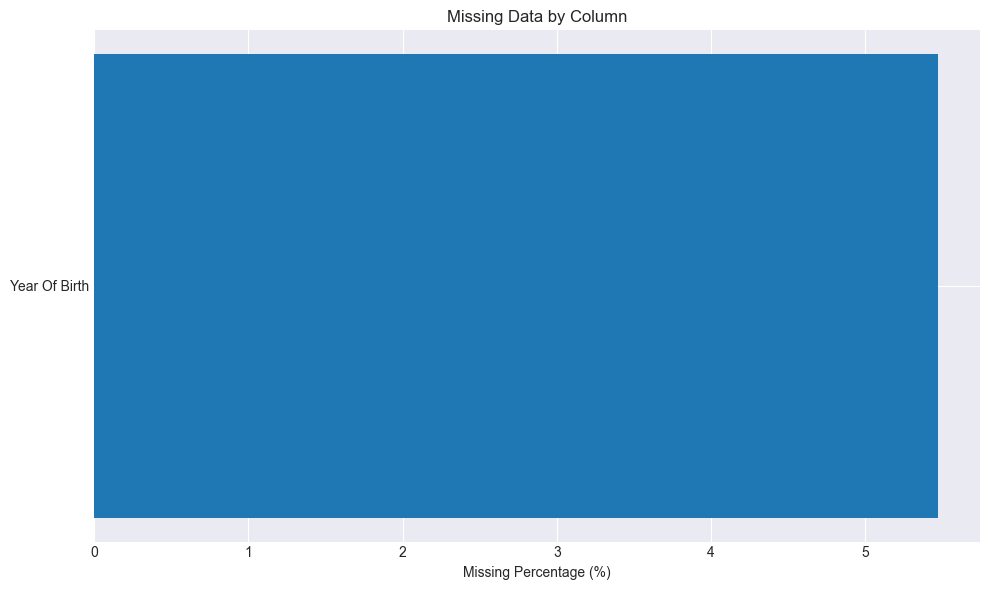

In [9]:
# Check for missing values
print("Missing Values Analysis:")
print("=" * 50)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    print(f"\nColumns with missing values:\n")
    print(missing_data.to_string(index=False))
    
    # Visualize missing data
    plt.figure(figsize=(10, 6))
    plt.barh(missing_data['Column'], missing_data['Missing_Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Data by Column')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found in the dataset!")

In [10]:
# Check for duplicate records
print("Duplicate Records Analysis:")
print("=" * 50)

total_duplicates = df.duplicated().sum()
duplicate_percentage = (total_duplicates / len(df) * 100).round(2)

print(f"\nTotal duplicate rows: {total_duplicates:,}")
print(f"Percentage of duplicates: {duplicate_percentage}%")

if total_duplicates > 0:
    print(f"\nFirst few duplicate rows:")
    duplicate_rows = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
    print(duplicate_rows.head(10))
else:
    print("\n✓ No duplicate rows found in the dataset!")

Duplicate Records Analysis:

Total duplicate rows: 0
Percentage of duplicates: 0.0%

✓ No duplicate rows found in the dataset!


## Key Columns Analysis

Analyze the distribution and characteristics of key columns in the dataset to understand the data better.

In [13]:
# Analyze unique values in key columns
print("Key Columns - Unique Values Analysis:")
print("=" * 50)

# Define potential key columns (adjust based on actual column names)
key_columns = [col for col in df.columns if col.lower() in 
               ['full_name', 'fullname', 'name', 'club', 'event', 'discipline', 
                'competition', 'gender', 'age_group', 'category']]

# If no predefined columns found, use all object/categorical columns
if not key_columns:
    key_columns = df.select_dtypes(include=['object']).columns.tolist()[:15]

for col in key_columns:
    if col in df.columns:
        unique_count = df[col].nunique()
        total_count = df[col].count()
        print(f"\n{col}:")
        print(f"  - Unique values: {unique_count:,}")
        print(f"  - Total non-null values: {total_count:,}")
        
        # Show top 10 most frequent values
        if unique_count > 0:
            top_values = df[col].value_counts().head(15)
            print(f"  - Top 15 most frequent:")
            for idx, (value, count) in enumerate(top_values.items(), 1):
                percentage = (count / total_count * 100).round(2)
                print(f"      {idx}. {str(value)[:40]} ({count:,} - {percentage}%)")

Key Columns - Unique Values Analysis:

Event:
  - Unique values: 27
  - Total non-null values: 50,827
  - Top 15 most frequent:
      1. 100m Freestyle (6,377 - 12.55%)
      2. 50m Freestyle (6,290 - 12.38%)
      3. 100m Backstroke (4,824 - 9.49%)
      4. 100m Breaststroke (4,233 - 8.33%)
      5. 200m Freestyle (3,448 - 6.78%)
      6. 200m Individual Medley (3,187 - 6.27%)
      7. 100m Butterfly (2,824 - 5.56%)
      8. 50m Butterfly (2,693 - 5.3%)
      9. 200m Backstroke (2,337 - 4.6%)
      10. 200m Breaststroke (2,011 - 3.96%)
      11. 400m Freestyle (1,970 - 3.88%)
      12. 100m Individual Medley (1,766 - 3.47%)
      13. 50m Breaststroke (1,648 - 3.24%)
      14. 200m Butterfly (1,375 - 2.71%)
      15. 50m Backstroke (1,251 - 2.46%)

Category:
  - Unique values: 61
  - Total non-null values: 50,827
  - Top 15 most frequent:
      1. Men 14-99 (5,383 - 10.59%)
      2. Women 13-99 (3,527 - 6.94%)
      3.  (3,400 - 6.69%)
      4. Women 14-99 (3,223 - 6.34%)
      5. Boys

## Next Steps

Based on the initial exploration above, here are recommended next steps:

1. **Data Cleaning**
   - Address any missing values identified in the quality check
   - Decide on handling strategy for duplicate records (if any)
   - Standardize text fields (names, clubs, events) for consistency

2. **Data Validation**
   - Validate time/result formats
   - Check for outliers or anomalous values
   - Verify date ranges and competition information

3. **Advanced Analysis**
   - Analyze performance trends over time
   - Compare results across competitions and categories
   - Identify top performers by event and club
   - Calculate statistics (means, percentiles) by category

4. **Data Preparation for Production**
   - Define business rules for data validation
   - Create data transformation pipeline
   - Prepare data for transfer to production tables

5. **Visualization**
   - Create distribution plots for key metrics
   - Build performance comparison charts
   - Generate competition participation visualizations